### UPSC Essay Example

Given a UPSC essay, we have to evaluate it based on Clarity of Thought (COT), Depth of Ananlysis (DOA), Language, have a feedback and score (out of 10) for each of these, then summarize the combined three feedbacks and give final average score.

This would need:
1. Parallel Worflow
2. Structured Output to make sure we get text feedback and numeric score from each of three aspects
3. Reducers, because:

State would have:
- essay_text
- cot_feedback
- doa_feedback
- lang_feedback
- final_feedback
- individual_score: now this will be a list containing 3 scores, and when scores from the 3 branches come in, instead of updating the same score key every time (this is langgraph default), we want to merge and append it
- final_score

In [13]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Annotated
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator # for reducer
load_dotenv()

True

In [ ]:
model = ChatOpenAI(model="gpt-4.1-nano")

In [5]:
class EvaluationSchema(BaseModel):

    feedback: str = Field(description="Detailed feedback for the essay")
    score: int = Field(description="Score out of 10", ge=0, le=10)

In [6]:
structured_model = model.with_structured_output(EvaluationSchema)

In [10]:
# trying strucured output
essay = 'The cat is on.'

In [11]:
prompt = f"Evaluate the language quality of the following essay and provide feedback and a score out of 10. Essay text: {essay}"

In [17]:
a = structured_model.invoke(prompt)
a

EvaluationSchema(feedback="The sentence 'The cat is on.' is incomplete and lacks clarity. It does not specify what the cat is on, which makes the statement unclear and grammatically fragmentary. For better coherence and grammatical correctness, consider providing more details or completing the sentence, such as 'The cat is on the couch.' Additionally, ensure that sentences are complete and convey the intended message clearly.", score=2)

In [18]:
a.feedback

"The sentence 'The cat is on.' is incomplete and lacks clarity. It does not specify what the cat is on, which makes the statement unclear and grammatically fragmentary. For better coherence and grammatical correctness, consider providing more details or completing the sentence, such as 'The cat is on the couch.' Additionally, ensure that sentences are complete and convey the intended message clearly."

In [19]:
a.score

2

In [ ]:

# now workflow

def evaluate_cot(state: EssayState): # we have no return type here because we are not returning the full state, but just a part of it. We can have a separate type for the output of each node, but for simplicity we can just return a dict and let the graph handle the merging of the state.

    prompt = f"Evaluate the following essay with a focus on the quality of the chain of thought reasoning. Provide detailed feedback and a score out of 10. Essay text: {state['essay']}"

    result = structured_model.invoke(prompt)

    return {
        'cot_feedback': result.feedback,
        'individual_scores': [result.score] # this is wrapped inside a list because we want to aggregate the scores later, so [8]+[7]+[5] works with opeartor.add to get [20]
    }

def evaluate_doa(state: EssayState):

    prompt = f"Evaluate the following essay with a focus on the quality of the depth of analysis. Provide detailed feedback and a score out of 10. Essay text: {state['essay']}"

    result = structured_model.invoke(prompt)

    return {
        'doa_feedback': result.feedback,
        'individual_scores': [result.score]
    }

def evaluate_lang(state: EssayState):

    prompt = f"Evaluate the following essay with a focus on the quality of the language. Provide detailed feedback and a score out of 10. Essay text: {state['essay']}"

    result = structured_model.invoke(prompt)

    return {
        'lang_feedback': result.feedback,
        'individual_scores': [result.score]
    }

def aggregate_feedback(state: EssayState):

    # summary feedback
    prompt = f'Based on the following feedback, provide an overall evaluation of the essay. Feedback: {state["cot_feedback"]} {state["doa_feedback"]} {state["lang_feedback"]}'
    result = model.invoke(prompt).content

    # avg score
    avg_score = sum(state['individual_scores']) / len(state['individual_scores'])

    return {
        'overall_feedback': result,
        'avg_score': avg_score
    }


In [30]:
class EssayState(TypedDict):

    essay: str
    cot_feedback: str
    doa_feedback: str
    lang_feedback: str
    overall_feedback: str
    #individual_scores: list[int] # we know we want this to be list of int, but we discussed how we want to merge it, so...
    individual_scores: Annotated[list[int], operator.add] # this is a hint to the reducer that we want to add these scores together in the list
    avg_score: float

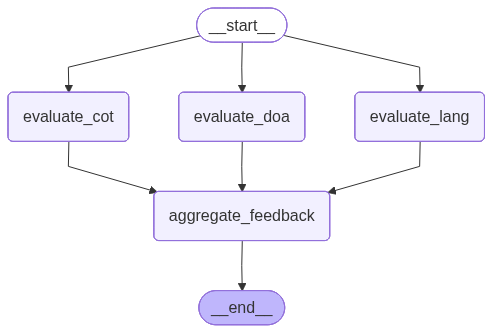

In [31]:
graph = StateGraph(EssayState)

graph.add_node('evaluate_cot', evaluate_cot)
graph.add_node('evaluate_doa', evaluate_doa)
graph.add_node('evaluate_lang', evaluate_lang)
graph.add_node('aggregate_feedback', aggregate_feedback)

graph.add_edge(START, 'evaluate_cot')
graph.add_edge(START, 'evaluate_doa')
graph.add_edge(START, 'evaluate_lang')
graph.add_edge('evaluate_cot', 'aggregate_feedback')
graph.add_edge('evaluate_doa', 'aggregate_feedback')
graph.add_edge('evaluate_lang', 'aggregate_feedback')
graph.add_edge('aggregate_feedback', END)

workflow = graph.compile()
workflow

In [32]:
initial_state = {'essay': 'The cat is on.'}
final_state = workflow.invoke(initial_state)
final_state

{'essay': 'The cat is on.',
 'cot_feedback': "The essay 'The cat is on.' presents a very brief statement that lacks context and elaboration. Because it is a fragment, the chain of thought is incomplete and does not demonstrate reasoning or development of ideas. To improve, the essay should expand on the situation, clarify what the cat is on, and perhaps include reflections or conclusions that show a logical progression of thought. As it stands, it does not effectively demonstrate reasoning or thought processes.",
 'doa_feedback': "The essay 'The cat is on.' is extremely brief and lacks depth in analysis. It does not provide any context, elaboration, or exploration of ideas related to the subject. As a result, it fails to demonstrate critical thinking, detailed examination, or a nuanced understanding of the topic. To improve, the essay should include more comprehensive content, such as descriptive details, insights, or discussion that explore the subject matter in depth.",
 'lang_feedba

In [33]:
sm = """
Artificial intelligence in healthcare is the application of artificial intelligence (AI) to analyze and understand complex medical and healthcare data. In some cases, it can exceed or augment human capabilities by providing better or faster ways to diagnose, treat, or prevent disease.[1][2][3]

As the widespread use of artificial intelligence in healthcare is still relatively new, research is ongoing into its applications across various medical subdisciplines and related industries. AI programs are being applied to practices such as diagnostics,[4] treatment protocol development,[5] drug development,[6] personalized medicine,[7] and patient monitoring and care.[8] Since radiographs are the most commonly performed imaging tests in radiology, the potential for AI to assist with triage and interpretation of radiographs is particularly significant.[9]
"""

In [34]:
initial_state1 = {'essay': sm}
final_state1 = workflow.invoke(initial_state1)
final_state1

{'essay': '\nArtificial intelligence in healthcare is the application of artificial intelligence (AI) to analyze and understand complex medical and healthcare data. In some cases, it can exceed or augment human capabilities by providing better or faster ways to diagnose, treat, or prevent disease.[1][2][3]\n\nAs the widespread use of artificial intelligence in healthcare is still relatively new, research is ongoing into its applications across various medical subdisciplines and related industries. AI programs are being applied to practices such as diagnostics,[4] treatment protocol development,[5] drug development,[6] personalized medicine,[7] and patient monitoring and care.[8] Since radiographs are the most commonly performed imaging tests in radiology, the potential for AI to assist with triage and interpretation of radiographs is particularly significant.[9]\n',
 'cot_feedback': 'The essay provides an overview of artificial intelligence in healthcare, outlining its applications and